# Profile: factor-views desk

The fourth profile is a **factor-aware desk that trades on factor views**. Where the
[desk monthly profile](02_Profile_Desk_Monthly.md) expressed a thesis directly on assets
("healthcare beats energy") through entropy pooling, this desk holds its convictions in
**factor space** — momentum will be rewarded, value will be rewarded — and lets a factor model
propagate those views to every asset. It then runs the resulting posterior through a *constrained*
optimiser, because a factor tilt left unchecked concentrates hard into whatever names load on the
favoured factors.

This is the pattern that the [advanced Black–Litterman](../2_moments_priors/06_Advanced_Black_Litterman.md)
page builds up variant by variant, assembled here end-to-end as a reusable book: a
`FactorBlackLittermanPrior`, real sector constraints, and an exact allocation.

The reasoning, following the [strategy decision framework](../../user_guide/06_Choosing_a_Strategy.md):

  - **The edge is a factor call, not a stock call** — the desk has a view on *factor premia*, so it
    encodes it where it belongs and propagates it through the factor regression.
  - **A raw factor tilt is dangerous** — momentum and value concentrate, so the book is wrapped in
    per-asset and per-sector caps that make the tilt expressible but bounded.
  - **Risk-adjusted, then allocated** — it takes the tangency (`MaximumRatio`) book on the
    posterior and turns it into whole shares with an exact MIP allocation.

> **When to reach for this**
>
> This is the template for a factor-driven book: when your conviction is about *factors*
> (momentum, value, quality, size, low-vol) rather than individual names, put the view in factor
> space with a factor Black–Litterman prior, then constrain the optimiser so the factor tilt
> diversifies into a real portfolio instead of a handful of high-loading names.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, HiGHS,
      StatsPlots, GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. Data, factors, and the factor view

We load the S&P 500 slice together with its factor block (`MTUM`, `QUAL`, `SIZE`, `USMV`, `VLUE`),
declare an asset `AssetSets` with sector groups (for the sector caps) and a factor `AssetSets` (for
the views), and write the desk's thesis as factor-premia views: momentum earns 5 bps/day and value
earns 3 bps/day.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
F = TimeArray(CSV.File(joinpath(@__DIR__, "..", "Factors.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X, F)
prices = vec(values(X)[end, :])

asset_sets = AssetSets(;
                       dict = Dict("nx" => rd.nx, "tech" => ["AAPL", "AMD", "MSFT"],
                                   "energy" => ["CVX", "XOM", "RRC"],
                                   "healthcare" => ["JNJ", "LLY", "MRK", "PFE", "UNH"]))
factor_sets = AssetSets(; dict = Dict("nx" => rd.nf))
tau = 1 / size(rd.X, 1)

factor_views = LinearConstraintEstimator(; val = ["MTUM == 0.0005", "VLUE == 0.0003"])

LinearConstraintEstimator
  val ┼ Vector{String}: ["MTUM == 0.0005", "VLUE == 0.0003"]
  key ┴ nothing


## 2. The factor Black–Litterman posterior

`FactorBlackLittermanPrior` takes the factor views, maps them through the asset-on-factor
regression, and returns a standard asset-space posterior `(mu, sigma)`. We keep the idiosyncratic
residual variance (`rsd = true`) so the posterior covariance is the full asset risk, not only its
factor-explained part.

In [3]:
prior_est = FactorBlackLittermanPrior(; pe = EmpiricalPrior(), rsd = true,
                                      sets = factor_sets, tau = tau, views = factor_views)
pr = prior(prior_est, rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

0.0001666666666666667

## 3. Why the constraints are not optional

Left unconstrained beyond a per-name cap, the tangency book on this posterior piles into the
sectors that load on the favoured factors. We solve it once with only a 15% per-asset cap to see
the raw tilt, then read off the sector totals.

In [4]:
raw = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                        opt = JuMPOptimiser(; pe = pr, slv = slv,
                                            wb = WeightBounds(; lb = 0.0, ub = 0.15),
                                            sets = asset_sets)))

sector_weight(w, sec) = sum(w[[findfirst(==(t), rd.nx) for t in asset_sets.dict[sec]]])
raw_sectors = DataFrame("sector" => ["tech", "energy", "healthcare"],
                        "raw tilt" => [sector_weight(raw.w, s)
                                       for s in ("tech", "energy", "healthcare")])
pretty_table(raw_sectors; formatters = [resfmt],
             title = "Sector weights with only a per-asset cap")

Sector weights with only a per-asset cap
┌────────────┬──────────┐
│     sector │ raw tilt │
│     String │  Float64 │
├────────────┼──────────┤
│       tech │    0.0 % │
│     energy │ 35.256 % │
│ healthcare │ 44.998 % │
└────────────┴──────────┘


The raw book leans heavily into healthcare and energy — the factor tilt expressed through the
names that load on momentum and value on this slice. That is the conviction working, but it is also
an undiversified book.

## 4. The constrained desk book

So the desk caps the two sectors the tilt favours — healthcare at 35% and energy at 25% — on top of
the 15% per-asset bound. The factor view still drives the *selection*, but the caps force it to
spread.

In [5]:
desk = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                         opt = JuMPOptimiser(; pe = pr, slv = slv,
                                             wb = WeightBounds(; lb = 0.0, ub = 0.15),
                                             lcse = LinearConstraintEstimator(;
                                                                              val = ["healthcare <= 0.35",
                                                                                     "energy <= 0.25"]),
                                             sets = asset_sets)))

constrained_sectors = DataFrame("sector" => ["tech", "energy", "healthcare"],
                                "constrained" => [sector_weight(desk.w, s)
                                                  for s in ("tech", "energy", "healthcare")])
pretty_table(constrained_sectors; formatters = [resfmt],
             title = "Sector weights after the 35% / 25% caps")

pretty_table(DataFrame("Asset" => rd.nx, "Weight" => desk.w); formatters = [resfmt],
             title = "Factor-views desk — constrained tangency book")

Sector weights after the 35% / 25% caps
┌────────────┬─────────────┐
│     sector │ constrained │
│     String │     Float64 │
├────────────┼─────────────┤
│       tech │       0.0 % │
│     energy │      25.0 % │
│ healthcare │      35.0 % │
└────────────┴─────────────┘
Factor-views desk — constrained tangency book
┌────────┬─────────┐
│  Asset │  Weight │
│ String │ Float64 │
├────────┼─────────┤
│   AAPL │   0.0 % │
│    AMD │   0.0 % │
│    BAC │   0.0 % │
│    BBY │   0.0 % │
│    CVX │  10.0 % │
│     GE │   0.0 % │
│     HD │   0.0 % │
│    JNJ │ 4.999 % │
│    JPM │   0.0 % │
│     KO │  15.0 % │
│    LLY │  15.0 % │
│    MRK │  15.0 % │
│   MSFT │   0.0 % │
│    PEP │  15.0 % │
│      ⋮ │       ⋮ │
└────────┴─────────┘
      6 rows omitted


Both sector caps bind: healthcare comes down to 35% and energy to 25%, and the freed weight spreads
into the rest of the universe. The book is still a factor-view portfolio — it just diversifies the
tilt instead of betting it all on the highest-loading names.

## 5. Exact finite allocation

On a \$1,000,000 book the desk wants the provably-best whole-share allocation, so it uses
`DiscreteAllocation` with a MIP solver ([HiGHS](https://github.com/jump-dev/HiGHS.jl)).

In [6]:
mip_slv = Solver(; name = :highs, solver = HiGHS.Optimizer,
                 settings = Dict("log_to_console" => false))
alloc = optimise(DiscreteAllocation(; slv = mip_slv),
                 FiniteAllocationInput(; w = desk.w, prices = prices, cash = 1_000_000.0))

invested = sum(alloc.shares .* prices)
pretty_table(DataFrame("Asset" => rd.nx, "Target" => desk.w,
                       "Shares" => round.(Int, alloc.shares), "Realised" => alloc.w);
             formatters = [resfmt],
             title = "\$1,000,000 allocated — invested \$$(round(Int, invested)), cash left \$$(round(alloc.cash, digits = 2))")

$1,000,000 allocated — invested $999983, cash left $16.93
┌────────┬─────────┬────────┬──────────┐
│  Asset │  Target │ Shares │ Realised │
│ String │ Float64 │  Int64 │  Float64 │
├────────┼─────────┼────────┼──────────┤
│   AAPL │   0.0 % │      0 │    0.0 % │
│    AMD │   0.0 % │      0 │    0.0 % │
│    BAC │   0.0 % │      0 │    0.0 % │
│    BBY │   0.0 % │      0 │    0.0 % │
│    CVX │  10.0 % │    576 │ 10.007 % │
│     GE │   0.0 % │      0 │    0.0 % │
│     HD │   0.0 % │      0 │    0.0 % │
│    JNJ │ 4.999 % │    287 │  4.996 % │
│    JPM │   0.0 % │      0 │    0.0 % │
│     KO │  15.0 % │   2395 │ 14.995 % │
│    LLY │  15.0 % │    413 │ 14.996 % │
│    MRK │  15.0 % │   1369 │ 15.002 % │
│   MSFT │   0.0 % │      0 │    0.0 % │
│    PEP │  15.0 % │    837 │ 15.006 % │
│      ⋮ │       ⋮ │      ⋮ │        ⋮ │
└────────┴─────────┴────────┴──────────┘
                          6 rows omitted


## 6. The book

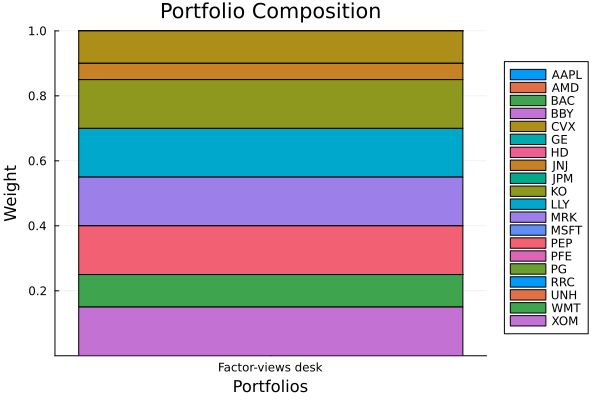

In [7]:
plot_stacked_bar_composition([desk], rd; xticks = (1:1, ["Factor-views desk"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*